# Gaussian Naïve Bayes (GNB)

In [1]:
from dependencies import *
from data_pipeline import load_pipeline, FEATURES

X_train_bal, y_train_bal, X_test_scaled, y_test, class_weight_dict, FEATURES, scaler = load_pipeline()


Loaded: (5569, 18)
Nulls before imputation:
pl_orbper       260
pl_orbsmax     2237
pl_orbeccen    3315
pl_bmasse      2986
pl_rade        1373
pl_eqt         2402
st_teff         290
st_rad          321
st_mass         206
st_lum          675
st_met          424
st_logg         351
st_age         1246
P_GRAVITY         7
P_DENSITY         7
P_ESCAPE          7
sy_dist         118
dtype: int64

[Tier 2a] pl_orbeccen: filled 3315 with 0.0
[Tier 2b] pl_orbsmax: filled 2203 via Kepler's 3rd law
[Tier 2c] pl_orbper: filled 242 via Kepler's 3rd law (inverse)
[Tier 2d] st_lum: filled 362 via Stefan-Boltzmann law
[Tier 2e] pl_bmasse: filled 2972 via mass-radius relation
[Tier 2f] pl_rade: filled 1359 via inverse mass-radius relation
[Tier 2g] pl_eqt: filled 2073 via equilibrium temp formula
[Tier 2h-j] P_GRAVITY/DENSITY/ESCAPE: filled 0 via physics formulas

Nulls after Tier 2:
pl_orbper        18
pl_orbsmax       34
pl_orbeccen       0
pl_bmasse        14
pl_rade          14
pl_eqt          

/Users/ahteshamalvi/PersonalProjects/exoplanet_ML_classification/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[Tier 4] RF Iterative Imputer on planetary features: 430 → 0 nulls
[Tier 5a] st_met: filled 424 via grouped median by spectral type
[Tier 5b] st_age: filled 1246 via RF regression + median fallback
[Tier 6] KNN imputer: 118 → 0 nulls

Train shape: (4455, 17)
Test shape:  (1114, 17)

Train distribution (BEFORE balancing):
P_HABITABLE
0.0    4399
1.0      23
2.0      33
Name: count, dtype: int64

Train distribution (AFTER balancing):
P_HABITABLE
0.0    299
1.0    200
2.0    199
Name: count, dtype: int64
Balanced train shape: (698, 17)
Class weights: {np.int64(0): np.float64(0.778149386845039), np.int64(1): np.float64(1.1633333333333333), np.int64(2): np.float64(1.169179229480737)}

Outputs ready for modeling:
  X_train_bal       → (698, 17) (balanced, scaled)
  y_train_bal       → 698 samples
  X_test_scaled     → (1114, 17) (held-out, scaled)
  y_test            → 1114 samples (original distribution)
  class_weight_dict → for class_weight param in classifiers


## Training

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# GAUSSIAN NAÏVE BAYES (GNB) — Baseline Classifier
# ══════════════════════════════════════════════════════════════════════════════
# GNB assumes features are independent and normally distributed per class.
# It has no class_weight parameter, so it relies entirely on the balanced
# training data from SMOTE. Expected to be the weakest model — sets the floor.

# ── Step 1: Tune var_smoothing ──
param_grid = {
    "var_smoothing": np.logspace(-12, -1, 25)
}

grid_gnb = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)
grid_gnb.fit(X_train_bal, y_train_bal)

# ── Step 2: Use best model ──
gnb = grid_gnb.best_estimator_

y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)

class_names = ["Non-Habitable", "Mesoplanet", "Psychroplanet"]
classes = np.array([0.0, 1.0, 2.0])
colors = ["#2196F3", "#FF9800", "#4CAF50"]

print("GNB training complete.")
print(f"Best var_smoothing: {grid_gnb.best_params_['var_smoothing']:.2e}")
print(f"Best CV F1 Macro:   {grid_gnb.best_score_:.4f}")

GNB training complete.
Best var_smoothing: 9.09e-07
Best CV F1 Macro:   0.8738


## Modeling
── GNB Diagnostic Plots: How the Model Works ──
### DIAGNOSTIC PLOT 1: Class-Conditional Gaussian Distributions (Top 6 Features)

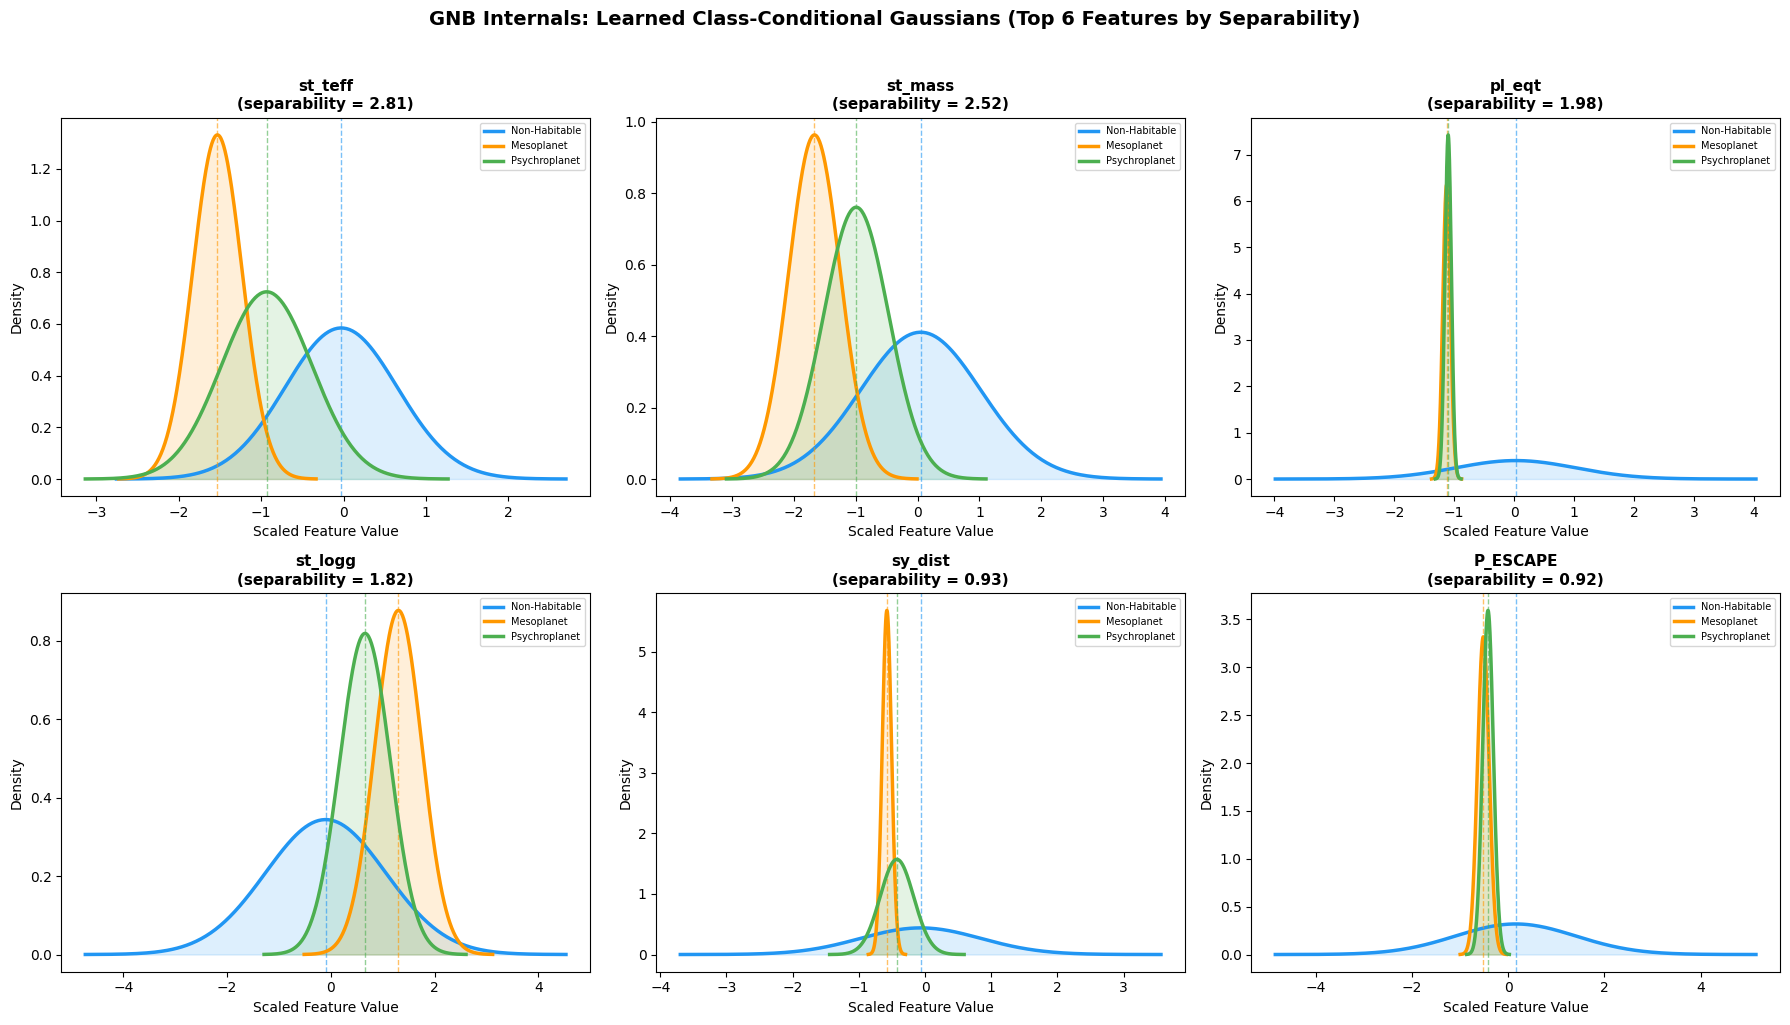

↑ Each curve is the Gaussian that GNB learned for that (feature, class) pair.
  Where curves overlap heavily → the model cannot distinguish classes on that feature alone.
  High separability = curves are far apart = more useful feature.



In [3]:
# ============================================================================
# PLOT 1: Class-Conditional Gaussian Distributions (Top 6 Features)
# ============================================================================

separability = []
for j, feat in enumerate(FEATURES):
    means = gnb.theta_[:, j]
    varis = gnb.var_[:, j]
    spread = means.max() - means.min()
    pooled_std = np.sqrt(np.mean(varis))
    separability.append((spread / (pooled_std + 1e-12), feat, j))

separability.sort(reverse=True)
top_features = separability[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax_idx, (sep_score, feat_name, feat_idx) in enumerate(top_features):
    ax = axes[ax_idx]

    for c in range(3):
        mu = gnb.theta_[c, feat_idx]
        sigma = np.sqrt(gnb.var_[c, feat_idx])

        x_range = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
        pdf = norm.pdf(x_range, mu, sigma)

        ax.plot(x_range, pdf, color=colors[c], lw=2.5, label=class_names[c])
        ax.fill_between(x_range, pdf, alpha=0.15, color=colors[c])
        ax.axvline(mu, color=colors[c], ls="--", lw=1, alpha=0.6)

    ax.set_title(f"{feat_name}\n(separability = {sep_score:.2f})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Scaled Feature Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle("GNB Internals: Learned Class-Conditional Gaussians (Top 6 Features by Separability)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("gnb_class_conditionals")
plt.show()

print("↑ Each curve is the Gaussian that GNB learned for that (feature, class) pair.")
print("  Where curves overlap heavily → the model cannot distinguish classes on that feature alone.")
print("  High separability = curves are far apart = more useful feature.\n")

### DIAGNOSTIC PLOT 2: Predicted Posterior Probability Distributions by True Class

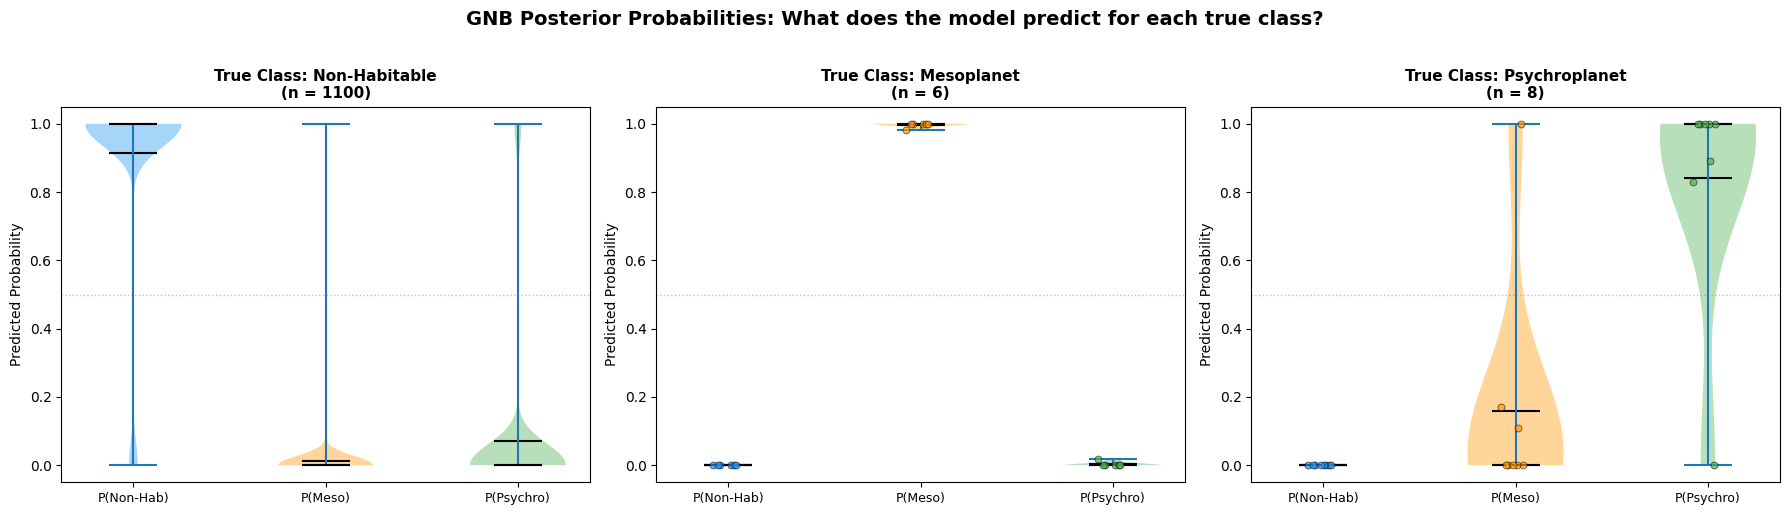

↑ For each true class, the violin shows the distribution of predicted probabilities.
  Ideal: for True Non-Habitable, P(Non-Hab) should be high and P(Meso)/P(Psychro) near 0.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for true_cls in range(3):
    ax = axes[true_cls]
    if hasattr(y_test, 'values'):
        mask = (y_test.values == float(true_cls))
    else:
        mask = (y_test == float(true_cls))
    probs = y_prob_gnb[mask]

    if probs.shape[0] == 0:
        ax.set_title(f"True: {class_names[true_cls]}\n(no samples in test set)")
        continue

    parts = ax.violinplot(
        [probs[:, c] for c in range(3)],
        positions=[0, 1, 2],
        showmeans=True,
        showmedians=True,
    )

    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.4)

    for key in ["cmeans", "cmedians"]:
        if key in parts:
            parts[key].set_color("black")

    if probs.shape[0] <= 50:
        for c in range(3):
            jitter = np.random.default_rng(42).normal(0, 0.04, size=probs.shape[0])
            ax.scatter(
                np.full(probs.shape[0], c) + jitter,
                probs[:, c],
                color=colors[c], s=25, alpha=0.7, edgecolors="black", linewidth=0.5, zorder=5
            )

    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["P(Non-Hab)", "P(Meso)", "P(Psychro)"], fontsize=9)
    ax.set_ylabel("Predicted Probability")
    ax.set_ylim([-0.05, 1.05])
    ax.set_title(f"True Class: {class_names[true_cls]}\n(n = {mask.sum()})",
                 fontsize=11, fontweight="bold")
    ax.axhline(0.5, color="gray", ls=":", lw=1, alpha=0.5)

fig.suptitle("GNB Posterior Probabilities: What does the model predict for each true class?",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("gnb_posteriors")
plt.show()

print("↑ For each true class, the violin shows the distribution of predicted probabilities.")
print("  Ideal: for True Non-Habitable, P(Non-Hab) should be high and P(Meso)/P(Psychro) near 0.")

## Metrics
### Classification Report + F1 Scores

GAUSSIAN NAÏVE BAYES — Classification Report
               precision    recall  f1-score   support

Non-Habitable     1.0000    0.9155    0.9559      1100
   Mesoplanet     0.2857    1.0000    0.4444         6
Psychroplanet     0.0814    0.8750    0.1489         8

     accuracy                         0.9156      1114
    macro avg     0.4557    0.9302    0.5164      1114
 weighted avg     0.9896    0.9156    0.9473      1114

F1 Macro:    0.5164
F1 Weighted: 0.9473

5-Fold CV F1 Macro: 0.8678 ± 0.0306


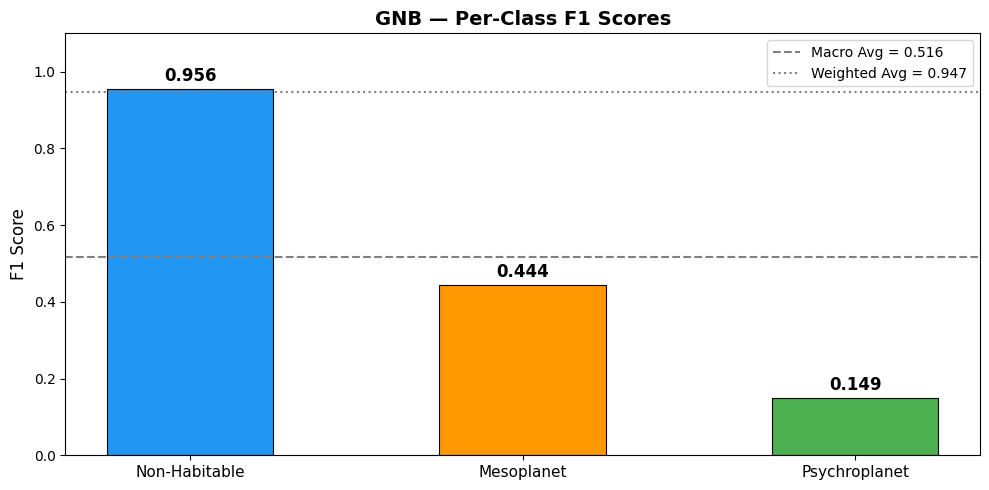

In [5]:
print("=" * 60)
print("GAUSSIAN NAÏVE BAYES — Classification Report")
print("=" * 60)
print(classification_report(y_test, y_pred_gnb, target_names=class_names, digits=4, zero_division=0))

f1_macro_gnb   = f1_score(y_test, y_pred_gnb, average="macro")
f1_weighted_gnb = f1_score(y_test, y_pred_gnb, average="weighted")
print(f"F1 Macro:    {f1_macro_gnb:.4f}")
print(f"F1 Weighted: {f1_weighted_gnb:.4f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gnb = cross_val_score(gnb, X_train_bal, y_train_bal, cv=cv, scoring="f1_macro")
print(f"\n5-Fold CV F1 Macro: {cv_scores_gnb.mean():.4f} ± {cv_scores_gnb.std():.4f}")

# ── Per-class F1 bar chart ──
f1_per_class = f1_score(y_test, y_pred_gnb, average=None, labels=classes, zero_division=0)

fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(class_names))
bars = ax.bar(x_pos, f1_per_class, color=colors, edgecolor="black", linewidth=0.8, width=0.5)

for bar, score in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{score:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.axhline(f1_macro_gnb, color="gray", ls="--", lw=1.5, label=f"Macro Avg = {f1_macro_gnb:.3f}")
ax.axhline(f1_weighted_gnb, color="gray", ls=":", lw=1.5, label=f"Weighted Avg = {f1_weighted_gnb:.3f}")
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("GNB — Per-Class F1 Scores", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
save_plot("gnb_f1_scores")
plt.show()

### Confusion Matrices (Counts + Normalized)

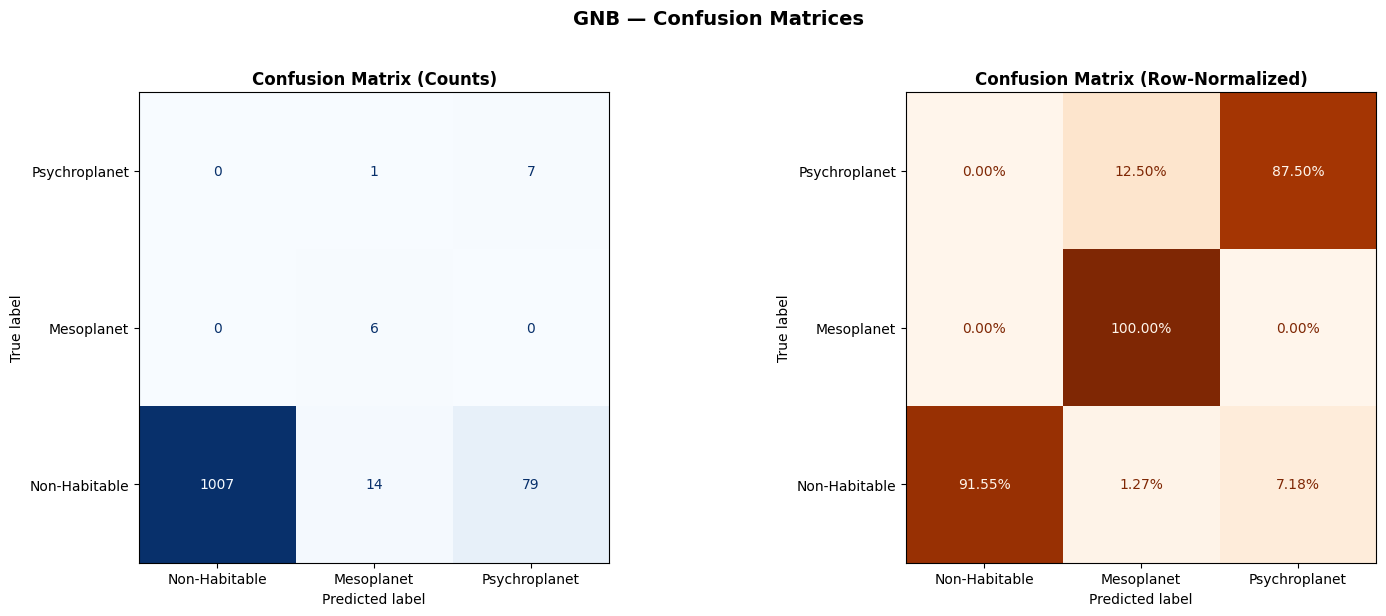

Key error patterns:
  Non-Habitable → predicted Mesoplanet: 14 (1.3% of true Non-Habitable)
  Non-Habitable → predicted Psychroplanet: 79 (7.2% of true Non-Habitable)
  Psychroplanet → predicted Mesoplanet: 1 (12.5% of true Psychroplanet)


In [6]:
cm_gnb = confusion_matrix(y_test, y_pred_gnb, labels=classes)
cm_gnb_norm = cm_gnb.astype(float) / cm_gnb.sum(axis=1, keepdims=True)
cm_gnb_norm = np.nan_to_num(cm_gnb_norm)

row_order = [2, 1, 0]
col_order = [0, 1, 2]
cm_gnb_reordered = cm_gnb[np.ix_(row_order, col_order)]
cm_gnb_norm_reordered = cm_gnb_norm[np.ix_(row_order, col_order)]

y_labels = [class_names[i] for i in row_order]
x_labels = [class_names[i] for i in col_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp1 = ConfusionMatrixDisplay(cm_gnb_reordered, display_labels=x_labels)
disp1.plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_yticklabels(y_labels)
axes[0].set_title("Confusion Matrix (Counts)", fontsize=12, fontweight="bold")

disp2 = ConfusionMatrixDisplay(cm_gnb_norm_reordered, display_labels=x_labels)
disp2.plot(ax=axes[1], cmap="Oranges", colorbar=False, values_format=".2%")
axes[1].set_yticklabels(y_labels)
axes[1].set_title("Confusion Matrix (Row-Normalized)", fontsize=12, fontweight="bold")

fig.suptitle("GNB — Confusion Matrices", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_plot("gnb_confusion_matrix")
plt.show()

print("Key error patterns:")
for i, true_name in enumerate(class_names):
    for j, pred_name in enumerate(class_names):
        if i != j and cm_gnb[i, j] > 0:
            print(f"  {true_name} → predicted {pred_name}: {cm_gnb[i, j]} "
                  f"({cm_gnb_norm[i, j]:.1%} of true {true_name})")

## Interpretation
The GNB baseline shows strong signal but poor reliability.

It performs very well on the dominant class (Non-Habitable), with near-perfect precision and high recall, which drives the overall accuracy (91.6%) and weighted F1 (0.95). It also achieves high recall across all classes, 100% for Mesoplanets and 87.5% for Psychroplanets, meaning it rarely misses habitable planets.

However, precision for the rare classes is extremely low, 28.6% for Mesoplanet and 8.1% for Psychroplanet. The model heavily over-predicts habitability, producing many false positives. Because those classes have very few true samples (6 and 8), even a small number of mistakes overwhelms the correct predictions, leading to a low macro F1 (0.52).

The gap between cross-validation (0.87) and test performance (0.52) shows the core issue: the model learns well on balanced (SMOTE) data but fails on the real, imbalanced distribution. This is compounded by Naïve Bayes assumptions—feature independence and Gaussian distributions—which don’t hold for correlated, skewed features.

Overall, the model confirms that the features contain strong predictive signal (high AUC), but it cannot produce reliable class decisions. It sets a useful baseline: future models need to improve macro F1 > 0.52 and especially precision on the minority classes.